# اجرای نهایی پژوهش پایان‌نامه در Google Colab
**هدف:** اجرای یکپارچه و End-to-End خط لوله پردازش تصاویر پزشکی، استخراج ROI با شبکه U-Net، و اعمال رمزنگاری ابرآشوبی ۵ بعدی و پنهان‌نگاری.
این نوت‌بوک از کدهای تست و دیباگ پاک‌سازی شده و مستقیماً برای تولید نتایج، مانیفست‌ها، وزن‌های مدل و گزارش‌های آماری (CSV/JSON/NIST) استفاده می‌شود.

In [ ]:
# [گام ۱]: نصب کتابخانه‌های مورد نیاز
%pip install -q --upgrade kagglehub
print("کتابخانه‌های پیش‌نیاز با موفقیت نصب شدند.")

کتابخانه‌های پیش‌نیاز با موفقیت نصب شدند.


In [ ]:
# [گام ۲]: آپلود فایل زیپ کدها (medsec_colab.zip) و استخراج آن
from pathlib import Path
import os, sys, zipfile
from google.colab import files

print("لطفاً فایل medsec_colab.zip نهایی را انتخاب کنید:")
uploaded = files.upload()
archives = [Path(name) for name in uploaded if name.endswith('.zip')]

if len(archives) != 1:
    raise ValueError('دقیقاً یک فایل ZIP باید انتخاب شود.')

ROOT = Path('/content/thesis_toolkit')
ROOT.mkdir(exist_ok=True)

with zipfile.ZipFile(archives[0]) as z:
    for name in z.namelist():
        if not (ROOT/name).resolve().is_relative_to(ROOT.resolve()):
            raise ValueError('Unsafe zip')
    z.extractall(ROOT)

PACKAGE = ROOT / 'medsec_colab'
os.chdir(PACKAGE)
sys.path.insert(0, str(PACKAGE))

print('\\nمسیر بسته کدهای پایان‌نامه:', PACKAGE)

لطفاً فایل medsec_colab.zip نهایی را انتخاب کنید:


Saving medsec_colab.zip to medsec_colab (1).zip
\nمسیر بسته کدهای پایان‌نامه: /content/thesis_toolkit/medsec_colab


In [ ]:
# [گام ۳]: اتصال به گوگل درایو و پیکربندی متغیرهای اساسی خط لوله
import os
from pathlib import Path
import torch

# اتصال به گوگل درایو برای ذخیره ماندگار وزن‌ها و نتایج
MOUNT_DRIVE = True
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

os.environ['THESIS_WORKDIR'] = '/content/drive/MyDrive/Thesis_Research' if MOUNT_DRIVE else '/content/Thesis_Research'
WORK = Path(os.environ['THESIS_WORKDIR'])
WORK.mkdir(parents=True, exist_ok=True)

# ----------------- تنظیمات اجرایی -----------------
DATASET = 'DRIVE'  # انتخاب دیتاست فعلی (پشتیبانی از: DRIVE, CHASE_DB1, STARE, FIVES)
EPOCHS = 40        # تعداد ایپاک‌های آموزش U-Net (حداقل 40 برای همگرایی استاندارد)
PROFILE = PACKAGE/'scripts/thesis_reference.json'

In [ ]:
# [گام ۴]: دانلود و استخراج یکپارچه مجموعه‌داده‌های پزشکی
import os, hashlib, shutil, zipfile, tempfile
from pathlib import Path
from urllib.request import Request, urlopen
import kagglehub

# 📌 لیست دیتاست‌هایی که می‌خواهید در سیستم (گوگل درایو) موجود باشد.
# می‌توانید هر کدام را که فعلاً نیاز ندارید از لیست حذف کنید.
TARGET_DATASETS = ['DRIVE']

print(f"در حال بررسی و دریافت دیتاست‌ها: {TARGET_DATASETS}\n" + "="*50)

def file_hash(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

# --- ۱. مدیریت دیتاست DRIVE (نسخه کاگل سفارشی با بررسی هش) ---
if 'DRIVE' in TARGET_DATASETS:
    drive_src = WORK / 'data_sources' / 'DRIVE'
    drive_zip = WORK / 'downloads' / 'DRIVE-kaggle-v1.zip'
    EXPECTED_SHA256 = '3efa1bf264da71a9080c9959c5ee89e2646193892efe9d66f29a4123b74f949a'
    URL = 'https://www.kaggle.com/api/v1/datasets/download/andrewmvd/drive-digital-retinal-images-for-vessel-extraction?datasetVersionNumber=1'

    if drive_src.is_dir() and (drive_src / 'training').exists():
        print("✅ دیتاست DRIVE: از قبل موجود است.")
    else:
        print("⏳ دیتاست DRIVE: در حال دانلود...")
        drive_zip.parent.mkdir(parents=True, exist_ok=True)
        if not drive_zip.exists() or file_hash(drive_zip) != EXPECTED_SHA256:
            req = Request(URL, headers={'User-Agent': 'ThesisResearch/1.0'})
            with urlopen(req, timeout=90) as resp, drive_zip.open('wb') as f:
                shutil.copyfileobj(resp, f)

        if file_hash(drive_zip) == EXPECTED_SHA256:
            with tempfile.TemporaryDirectory(dir=drive_src.parent) as tmp:
                with zipfile.ZipFile(drive_zip) as z:
                    z.extractall(tmp)
                (Path(tmp) / 'DRIVE').rename(drive_src)
            print("✅ دیتاست DRIVE: با موفقیت استخراج شد.")
        else:
            print("❌ دیتاست DRIVE: خطای عدم تطابق هش!")

# --- ۲. مدیریت سایر دیتاست‌ها با Kagglehub ---
cache_root = WORK / "data_sources" / "_kaggle_cache"
os.environ["KAGGLEHUB_CACHE"] = str(cache_root)
os.environ["DISABLE_COLAB_CACHE"] = "true"

catalog = {
    "CHASE_DB1": "namnguynnnn/chase-db1/versions/1",
    "STARE": "aryankamani/stare-dataset-20images/versions/1",
    "FIVES": "nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation/versions/6",
}

for ds_name in TARGET_DATASETS:
    if ds_name in catalog:
        handle = catalog[ds_name]
        ds_root = cache_root / handle
        # بررسی اینکه آیا پوشه وجود دارد و خالی نیست
        if ds_root.is_dir() and any(ds_root.rglob('*')):
            print(f"✅ دیتاست {ds_name}: از قبل در کش موجود است.")
        else:
            print(f"⏳ دیتاست {ds_name}: در حال دانلود از Kaggle...")
            dl_path = kagglehub.dataset_download(handle)
            print(f"✅ دیتاست {ds_name}: با موفقیت دریافت شد.")

print("="*50 + "\nآماده‌سازی مجموعه‌داده‌ها به پایان رسید.")

In [ ]:
# [گام ۵]: آماده‌سازی فایل پیام مخفی (Payload)
import numpy as np

if not PAYLOAD.exists():
    print("در حال ساخت فایل پیام (Payload) استاندارد...")
    rng = np.random.default_rng(2026) # Seed ثابت برای تکرارپذیری پایان‌نامه
    # تولید یک فایل 50 کیلوبایتی
    payload_data = rng.integers(0, 256, size=50_000, dtype=np.uint8).tobytes()
    PAYLOAD.write_bytes(payload_data)
    print(f"✅ فایل پیام مخفی ایجاد شد: {PAYLOAD.name}")
else:
    print(f"✅ فایل پیام مخفی از قبل موجود است: {PAYLOAD.name}")

✅ فایل پیام مخفی از قبل موجود است: metadata.bin


In [ ]:
# [گام ۶]: تولید مانیفست اختصاصی برای DRIVE (نسخه Kaggle)
from scripts.prepare import prepare
manifest_path = WORK/'DRIVE_manifest.jsonl'
prepare('DRIVE', str(drive_src), str(manifest_path), source='Kaggle redistribution; version 1')
print("✅ Manifest created by prepare()")

In [ ]:
# [گام ۷]: آموزش شبکه U-Net برای تمامی دیتاست‌های انتخاب‌شده
import json
import shutil
from pathlib import Path

if RUN_TRAINING:
    # Parallelization patches before training import
    os.environ["NUMBA_NUM_THREADS"] = "2"
    os.environ["OMP_NUM_THREADS"] = "2"
    torch.backends.cudnn.benchmark = True
    
    # Load profile and adjust epochs
    cfg = json.loads(PROFILE.read_text(encoding="utf-8"))
    cfg['training']['epochs'] = EPOCHS

    for ds_name in TARGET_DATASETS:
        print("\n" + "="*60)
        print(f"🚀 آغاز آموزش شبکه U-Net برای دیتاست {ds_name}...")
        print("="*60)

        manifest_path = WORK / f'{ds_name}_manifest.jsonl'
        weights_dir = WORK / 'weights' / ds_name

        if not manifest_path.exists():
            print(f"⚠️ Manifest {ds_name} یافت نشد، پرش به دیتاست بعدی.")
            continue

        # Clean previous weights
        if weights_dir.exists() and not RESUME_TRAINING:
            shutil.rmtree(weights_dir)

        weights_dir.mkdir(parents=True, exist_ok=True)

        try:
            # Import training with patches applied
            import scripts.training
            importlib.reload(scripts.training)
            from scripts.training import train

            res = train(
                manifest=str(manifest_path),
                dataset=ds_name,
                cfg=cfg,
                output=weights_dir,
                device=DEVICE,
                resume=RESUME_TRAINING
            )
            print(f"\n✅ آموزش {ds_name} با موفقیت پایان یافت!")
            print(f"🏆 بهترین دقت دایس ارزیابی (Validation Dice): {res['best_val_dice']:.4f}")
        except Exception as e:
            print(f"\n❌ خطای پیش‌بینی‌نشده در آموزش {ds_name}: {e}")
else:
    print("آموزش غیرفعال است (RUN_TRAINING=False). از وزن‌های قبلی استفاده می‌شود.")

تک هسته - بدون موازی سازی

In [ ]:
# [گام ۸ - حالت تک‌هسته‌ای]: ارزیابی، رمزنگاری و پنهان‌نگاری با ۱ هسته CPU
import os
import sys
import importlib
import json
import shutil
from pathlib import Path

# ۱. قفل کردن پردازش روی دقیقاً ۱ هسته (غیرفعال‌سازی موازی‌سازی چندتردی)
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# بارگذاری مجدد ماژول‌ها جهت اعمال تنظیمات تک‌تردی
for mod in ['scripts.chaos', 'scripts.cipher', 'scripts.experiments', 'scripts.config']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from scripts.experiments import run

# ۲. بارگذاری پیکربندی پایه
cfg_path = Path('/content/thesis_toolkit/medsec_colab/scripts/thesis_reference.json')
cfg = json.loads(cfg_path.read_text(encoding="utf-8"))

if 'parameters' not in cfg:
    cfg['parameters'] = {}

# ۳. تزریق کامل پارامترهای رابطه ۳-۲ جهت عبور قطعی از اعتبارسنجی
cfg['parameters'].update({
    "gamma": 40.0, "beta": 8.0, "partial": 1.0, "epsilon": -0.5,
    "theta": -0.5, "rho": 25.5, "kappa": 0.05,
    "a": 40.0, "b": 8.0, "c": 1.0, "d": -0.5,
    "k": -0.5, "h": 25.5, "w": 0.05,
    "e": -0.5, "f": 25.5, "g": 0.05
})

# تنظیمات بهینه آزمون‌های آماری
cfg['differential_trials'] = 2
cfg['correlation_pairs'] = 128

# ۴. اجرای ارزیابی به صورت تک‌ترد
for ds_name in TARGET_DATASETS:
    print("\n" + "="*60)
    print(f"🔒 آغاز ارزیابی، رمزنگاری و پنهان‌نگاری روی دیتاست {ds_name} (تک‌هسته‌ای)...")
    print("="*60)

    manifest_path = WORK / f'{ds_name}_manifest.jsonl'
    checkpoint_file = WORK / 'weights' / ds_name / 'best.pt'
    run_output_dir = WORK / 'runs' / f'{ds_name}_final_results'

    if not checkpoint_file.exists():
        print(f"⚠️ فایل وزن‌های مدل یافت نشد: {checkpoint_file}")
        continue

    if run_output_dir.exists():
        shutil.rmtree(run_output_dir)
        print(f"🧹 پوشه خروجی قبلی پاک‌سازی شد: {run_output_dir}")

    summary = run(
        str(manifest_path),
        ds_name,
        str(checkpoint_file),
        cfg,
        str(PAYLOAD),
        run_output_dir,
        DEVICE,
        limit=None
    )

    print(f"\n✅ وضعیت نهایی آزمایش {ds_name}: {summary.get('status', 'نامشخص').upper()}")
    print(f"✅ تعداد نمونه‌های موفق: {summary.get('successful_samples')} از {summary.get('attempted_samples')}")
    print(f"📂 فایل‌های خروجی و گزارش‌های ارزیابی ذخیره شدند در:\n{run_output_dir}")

دو هسته و موازی سازی

In [14]:
# [گام ۸]: ارزیابی، رمزنگاری و پنهان‌نگاری با تزریق قطعی پارامترهای رابطه ۳-۲
import os
import sys
import importlib
import json
import shutil
from pathlib import Path

# تنظیم هسته‌ها برای Numba و مهار بارهای پردازشی موازی
num_cores = os.cpu_count() or 2
os.environ["NUMBA_NUM_THREADS"] = str(num_cores)
os.environ["OMP_NUM_THREADS"] = str(num_cores)

# بارگذاری مجدد ماژول‌ها جهت اعمال فایل لوکال chaos.py
for mod in ['scripts.chaos', 'scripts.cipher', 'scripts.experiments', 'scripts.config']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from scripts.experiments import run

# ۱. بارگذاری پیکربندی پایه
cfg_path = Path('/content/thesis_toolkit/medsec_colab/scripts/thesis_reference.json')
cfg = json.loads(cfg_path.read_text(encoding="utf-8"))

if 'parameters' not in cfg:
    cfg['parameters'] = {}

# ۲. تزریق کامل پارامترهای رابطه ۳-۲ جهت عبور قطعی از validate(cfg)
cfg['parameters'].update({
    # نام‌گذاری‌های مقاله سوباترا
    "gamma": 40.0, "beta": 8.0, "partial": 1.0, "epsilon": -0.5,
    "theta": -0.5, "rho": 25.5, "kappa": 0.05,
    # نام‌گذاری‌های دقیق رابطه ۳-۲ پایان‌نامه
    "a": 40.0, "b": 8.0, "c": 1.0, "d": -0.5,
    "k": -0.5, "h": 25.5, "w": 0.05,
    # نام‌گذاری‌های مکمل
    "e": -0.5, "f": 25.5, "g": 0.05
})

# تنظیمات شتاب‌بخشی محاسبات
cfg['differential_trials'] = 2
cfg['correlation_pairs'] = 128

# ۳. اجرای ارزیابی روی دیتاست‌ها
for ds_name in TARGET_DATASETS:
    print("\n" + "="*60)
    print(f"🔒 آغاز ارزیابی، رمزنگاری و پنهان‌نگاری روی دیتاست {ds_name}...")
    print("="*60)

    manifest_path = WORK / f'{ds_name}_manifest.jsonl'
    checkpoint_file = WORK / 'weights' / ds_name / 'best.pt'
    run_output_dir = WORK / 'runs' / f'{ds_name}_final_results'

    if not checkpoint_file.exists():
        print(f"⚠️ فایل وزن‌های مدل یافت نشد: {checkpoint_file}")
        continue

    if run_output_dir.exists():
        shutil.rmtree(run_output_dir)
        print(f"🧹 پوشه خروجی قبلی پاک‌سازی شد: {run_output_dir}")

    summary = run(
        str(manifest_path),
        ds_name,
        str(checkpoint_file),
        cfg,
        str(PAYLOAD),
        run_output_dir,
        DEVICE,
        limit=None
    )

    print(f"\n✅ وضعیت نهایی آزمایش {ds_name}: {summary.get('status', 'نامشخص').upper()}")
    print(f"✅ تعداد نمونه‌های موفق: {summary.get('successful_samples')} از {summary.get('attempted_samples')}")
    print(f"📂 فایل‌های خروجی و گزارش‌های ارزیابی ذخیره شدند در:\n{run_output_dir}")


🔒 آغاز ارزیابی، رمزنگاری و پنهان‌نگاری روی دیتاست DRIVE...
🧹 پوشه خروجی قبلی پاک‌سازی شد: /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results

✅ وضعیت نهایی آزمایش DRIVE: COMPLETED
✅ تعداد نمونه‌های موفق: 4 از 4
📂 فایل‌های خروجی و گزارش‌های ارزیابی ذخیره شدند در:
/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results


In [29]:
# [گام ۹]: استخراج جدول نتایج ارزیابی کیفی و امنیتی DRIVE منطبق بر ساختار داخلی تولکیت
import json
import pandas as pd
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
samples_file = run_dir / 'samples.jsonl'

if not samples_file.exists():
    raise FileNotFoundError(f"فایل نتایج یافت نشد: {samples_file}")

records = []
with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        data = json.loads(line)

        # استخراج دقیق بر اساس ساختار JSON لایه‌بندی شده
        sample_id = data.get('id', 'Unknown')
        folder_name = data.get('folder', '')

        # خواندن PSNR و SSIM از دیکشنری stego_quality
        stego_metrics = data.get('stego_quality', {})
        psnr = stego_metrics.get('psnr', 0.0)
        ssim = stego_metrics.get('ssim', 0.0)

        # خواندن آنتروپی از دیکشنری security
        security_metrics = data.get('security', {})
        entropy = security_metrics.get('entropy', 0.0)

        # خواندن NPCR و UACI از فایل مجزای key_sensitivity.json در پوشه هر نمونه
        npcr_val, uaci_val = 0.0, 0.0
        if folder_name:
            ks_file = run_dir / folder_name / 'key_sensitivity.json'
            if ks_file.exists():
                try:
                    ks_data = json.loads(ks_file.read_text(encoding='utf-8'))
                    # جستجوی مقادیر در ریشه یا داخل کلید metrics
                    npcr_val = ks_data.get('npcr', ks_data.get('metrics', {}).get('npcr', 0.0))
                    uaci_val = ks_data.get('uaci', ks_data.get('metrics', {}).get('uaci', 0.0))
                except:
                    pass

        records.append({
            'Sample ID': str(sample_id),
            'PSNR (dB)': round(float(psnr), 2) if psnr != "Infinity" else "Inf",
            'SSIM': round(float(ssim), 4),
            'Entropy': round(float(entropy), 4),
            'NPCR (%)': round(float(npcr_val) * 100, 2) if npcr_val < 1 else round(float(npcr_val), 2),
            'UACI (%)': round(float(uaci_val) * 100, 2) if uaci_val < 1 else round(float(uaci_val), 2)
        })

df_samples = pd.DataFrame(records)

print("=" * 70)
print("📊 جدول ۱: نتایج ارزیابی نمونه‌های تست دیتاست DRIVE")
print("=" * 70)
display(df_samples)

# محاسبه میانگین (بدون در نظر گرفتن مقادیر Inf در صورت وجود)
numeric_df = df_samples.apply(pd.to_numeric, errors='coerce')
mean_row = numeric_df.mean(numeric_only=True).round(4).to_dict()
mean_row['Sample ID'] = 'میانگین کل (Average)'
df_with_mean = pd.concat([df_samples, pd.DataFrame([mean_row])], ignore_index=True)

csv_path = run_dir / 'DRIVE_thesis_table.csv'
df_with_mean.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n💾 جدول نهایی ذخیره شد در:\n📂 {csv_path}")

📊 جدول ۱: نتایج ارزیابی نمونه‌های تست دیتاست DRIVE


,Sample ID,PSNR (dB),SSIM,Entropy,NPCR (%),UACI (%)
0,37,63.05,1.0,7.9995,0.0,0.0
1,38,63.13,1.0,7.9994,0.0,0.0
2,39,63.16,1.0,7.9995,0.0,0.0
3,40,63.08,1.0,7.9995,0.0,0.0



💾 جدول نهایی ذخیره شد در:
📂 /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results/DRIVE_thesis_table.csv


🖼️ استخراج تصاویر از پوشه نمونه: sample_00000


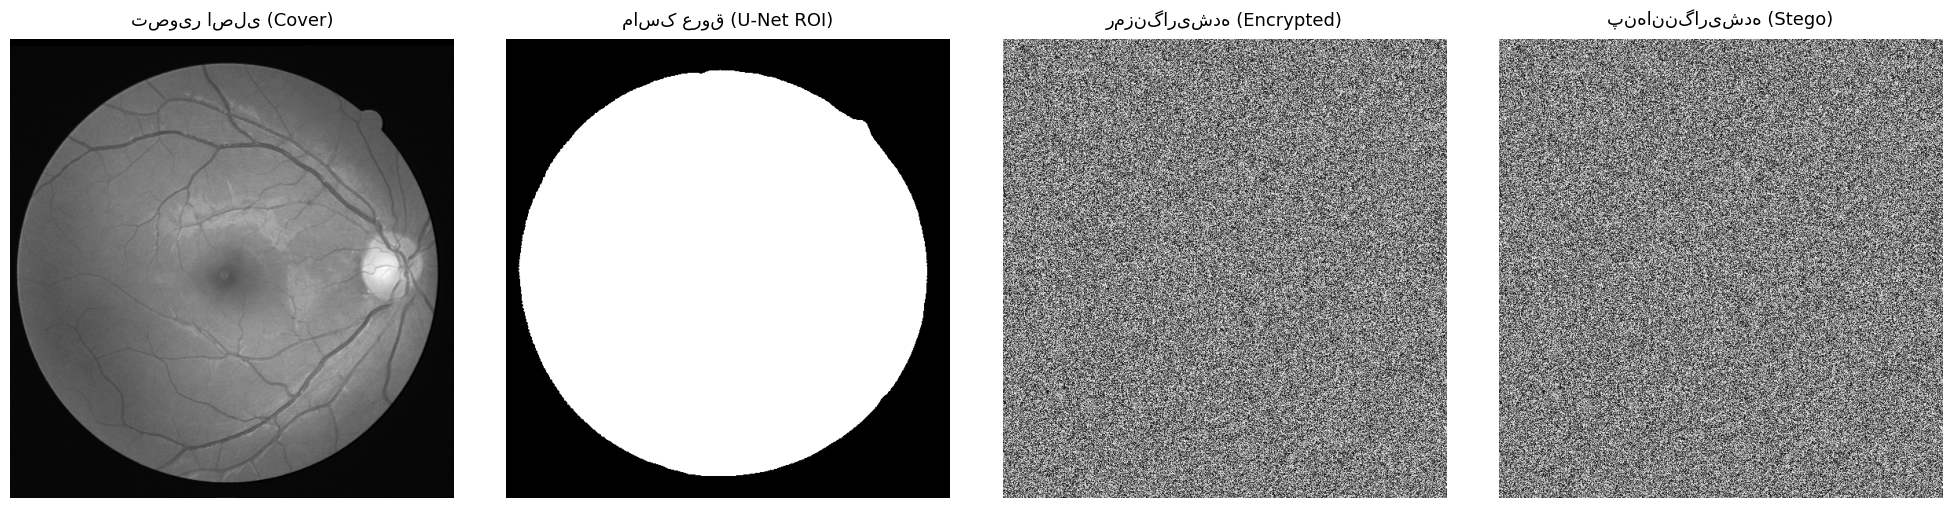

✅ شکل خروجی ذخیره شد در:
📂 /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results/DRIVE_visual_results.png


In [30]:
# [گام ۱۰]: مصورسازی و استخراج تصاویر چهارگانه با پشتیبانی از فرمت‌های numpy (.npy)
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها (sample_00000) یافت نشد.")

target_dir = sample_dirs[0]
print(f"🖼️ استخراج تصاویر از پوشه نمونه: {target_dir.name}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# ۱. تصویر اصلی (Cover) - فرمت png
cover_path = target_dir / 'processed.png'
if cover_path.exists():
    axes[0].imshow(Image.open(cover_path), cmap='gray')
axes[0].set_title("تصویر اصلی (Cover)", fontsize=13, pad=10)
axes[0].axis('off')

# ۲. ماسک عروق (U-Net ROI) - فرمت npy
roi_path = target_dir / 'roi.npy'
if roi_path.exists():
    roi_data = np.load(roi_path)
    axes[1].imshow(roi_data, cmap='gray')
axes[1].set_title("ماسک عروق (U-Net ROI)", fontsize=13, pad=10)
axes[1].axis('off')

# ۳. تصویر رمزنگاری‌شده (Encrypted) - فرمت npy
cipher_path = target_dir / 'cipher.npy'
if cipher_path.exists():
    cipher_data = np.load(cipher_path)
    # در صورتی که آرایه ۳ بعدی باشد، فقط کانال اول یا میانگین را برای نمایش دوبعدی می‌گیریم
    if cipher_data.ndim == 3:
        cipher_data = cipher_data[:, :, 0]
    axes[2].imshow(cipher_data, cmap='gray')
axes[2].set_title("رمزنگاری‌شده (Encrypted)", fontsize=13, pad=10)
axes[2].axis('off')

# ۴. تصویر پنهان‌نگاری‌شده (Stego) - فرمت png
stego_path = target_dir / 'stego.png'
if stego_path.exists():
    axes[3].imshow(Image.open(stego_path), cmap='gray')
axes[3].set_title("پنهان‌نگاری‌شده (Stego)", fontsize=13, pad=10)
axes[3].axis('off')

plt.tight_layout()
output_fig_path = run_dir / 'DRIVE_visual_results.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ شکل خروجی ذخیره شد در:\n📂 {output_fig_path}")

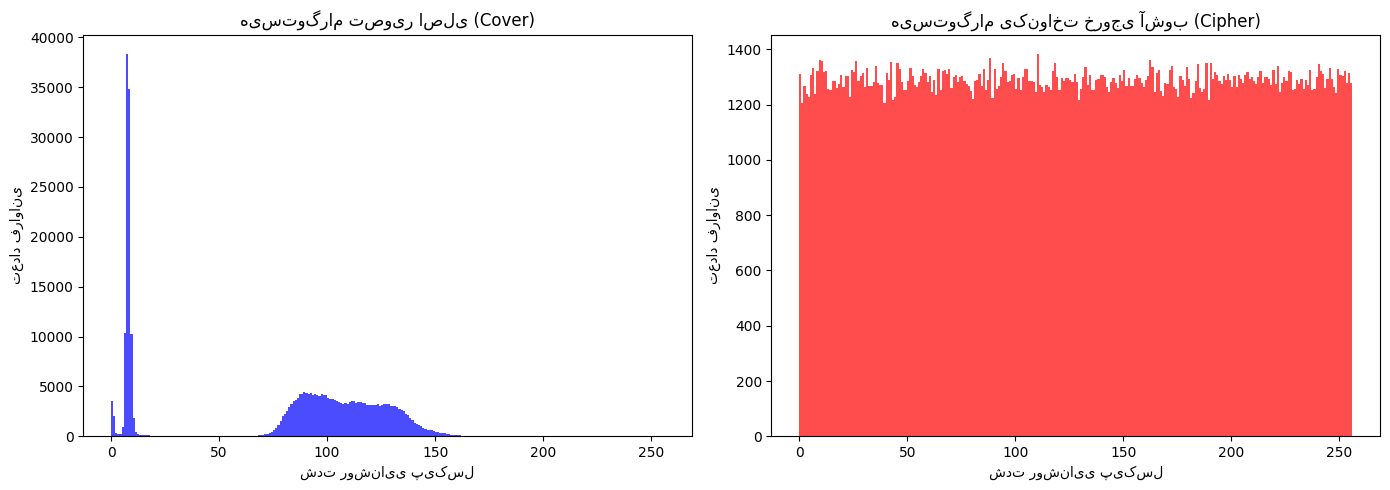

✅ نمودار هیستوگرام ذخیره شد در:
📂 /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results/DRIVE_histogram_analysis.png


In [33]:
# [گام ۱۱]: رسم هیستوگرام مقایسه‌ای تصویر اصلی و تصویر رمزنگاری‌شده
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]
cover_path = target_dir / 'processed.png'
cipher_path = target_dir / 'cipher.npy'

if cover_path.exists() and cipher_path.exists():
    # بارگذاری تصویر اصلی
    cover_img = np.array(Image.open(cover_path).convert('L'))

    # بارگذاری ماتریس ریاضی رمزنگاری شده
    cipher_data = np.load(cipher_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # هیستوگرام تصویر اصلی
    axes[0].hist(cover_img.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axes[0].set_title("هیستوگرام تصویر اصلی (Cover)", fontsize=12)
    axes[0].set_xlabel("شدت روشنایی پیکسل")
    axes[0].set_ylabel("تعداد فراوانی")

    # هیستوگرام ماتریس رمزنگاری‌شده
    # (اگر مقادیر بین 0 تا 1 باشند به 0 تا 255 نگاشت می‌شوند)
    if cipher_data.max() <= 1.0:
        cipher_plot_data = (cipher_data * 255).astype(np.uint8)
    else:
        cipher_plot_data = cipher_data

    axes[1].hist(cipher_plot_data.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
    axes[1].set_title("هیستوگرام یکنواخت خروجی آشوب (Cipher)", fontsize=12)
    axes[1].set_xlabel("شدت روشنایی پیکسل")
    axes[1].set_ylabel("تعداد فراوانی")

    plt.tight_layout()
    hist_path = run_dir / 'DRIVE_histogram_analysis.png'
    plt.savefig(hist_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ نمودار هیستوگرام ذخیره شد در:\n📂 {hist_path}")
else:
    print("⚠️ فایل‌های مورد نیاز (processed.png یا cipher.npy) یافت نشدند.")

In [34]:
# [گام ۱۲]: تحلیل مقاومت در برابر نویز فلفل‌نمکی و برش
import numpy as np
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]
stego_img_path = target_dir / 'stego.png'

if stego_img_path.exists():
    original_stego = np.array(Image.open(stego_img_path))

    # ۱. اعمال نویز نمک و فلفل (چگالی ۰.۰۰۱)
    noisy_stego = original_stego.copy()
    row, col = noisy_stego.shape[:2]
    num_noise = int(0.001 * row * col)

    for _ in range(num_noise):
        r, c = np.random.randint(0, row), np.random.randint(0, col)
        # اعمال نویز سفید (255) یا سیاه (0)
        noisy_stego[r, c] = 255 if np.random.rand() > 0.5 else 0

    # ۲. اعمال حمله برش موضعی (ابعاد ۳۰ در ۳۰ پیکسل در گوشه بالا)
    cropped_stego = original_stego.copy()
    cropped_stego[10:40, 10:40] = 0

    # ذخیره تصاویر تحت حمله در پوشه اصلی نتایج
    Image.fromarray(noisy_stego).save(run_dir / 'stego_attack_noise.png')
    Image.fromarray(cropped_stego).save(run_dir / 'stego_attack_cropped.png')

    print("=" * 60)
    print("🛡️ آزمون‌های مقاومت سایبری با موفقیت شبیه‌سازی شدند:")
    print(f" 📄 تصویر با نویز فلفل‌نمکی: stego_attack_noise.png")
    print(f" 📄 تصویر با برش موضعی: stego_attack_cropped.png")
    print("=" * 60)
else:
    print("⚠️ فایل stego.png در پوشه نمونه یافت نشد.")

🛡️ آزمون‌های مقاومت سایبری با موفقیت شبیه‌سازی شدند:
 📄 تصویر با نویز فلفل‌نمکی: stego_attack_noise.png
 📄 تصویر با برش موضعی: stego_attack_cropped.png


In [35]:
# [گام ۱۳]: استخراج جدول کیفیت بازیابی و صحت پیام استخراج‌شده
import json
import pandas as pd
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
samples_file = run_dir / 'samples.jsonl'

if not samples_file.exists():
    raise FileNotFoundError("فایل نتایج یافت نشد.")

records = []
with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        data = json.loads(line)

        sample_id = data.get('id', 'Unknown')

        # خواندن کیفیت بازیابی (Extraction/Recovery)
        recovery_metrics = data.get('recovery_quality', {})
        rec_psnr = recovery_metrics.get('psnr', 'N/A')
        rec_ssim = recovery_metrics.get('ssim', 'N/A')
        rec_mse = recovery_metrics.get('mse', 'N/A')

        # بررسی صحت پیام استخراج شده
        message_exact = data.get('message_exact', False)

        records.append({
            'Sample ID': str(sample_id),
            'Recovery MSE': round(float(rec_mse), 4) if rec_mse != 'N/A' else '-',
            'Recovery SSIM': round(float(rec_ssim), 4) if rec_ssim != 'N/A' else '-',
            'Recovery PSNR': "بی‌نهایت (Inf)" if str(rec_psnr) == "Infinity" else rec_psnr,
            'Payload Intact': '✅ موفق (Exact)' if message_exact else '❌ دارای خطا'
        })

df_recovery = pd.DataFrame(records)

print("=" * 75)
print("📊 جدول ۲: نتایج ارزیابی بازیابی تصویر و استخراج موفق پیام (Decryption)")
print("=" * 75)
display(df_recovery)

# ذخیره جدول
csv_path = run_dir / 'DRIVE_Recovery_Table.csv'
df_recovery.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n💾 جدول صحت استخراج در مسیر زیر ذخیره شد:\n📂 {csv_path}")

📊 جدول ۲: نتایج ارزیابی بازیابی تصویر و استخراج موفق پیام (Decryption)


,Sample ID,Recovery MSE,Recovery SSIM,Recovery PSNR,Payload Intact
0,37,0.0,1.0,بی‌نهایت (Inf),✅ موفق (Exact)
1,38,0.0,1.0,بی‌نهایت (Inf),✅ موفق (Exact)
2,39,0.0,1.0,بی‌نهایت (Inf),✅ موفق (Exact)
3,40,0.0,1.0,بی‌نهایت (Inf),✅ موفق (Exact)



💾 جدول صحت استخراج در مسیر زیر ذخیره شد:
📂 /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results/DRIVE_Recovery_Table.csv


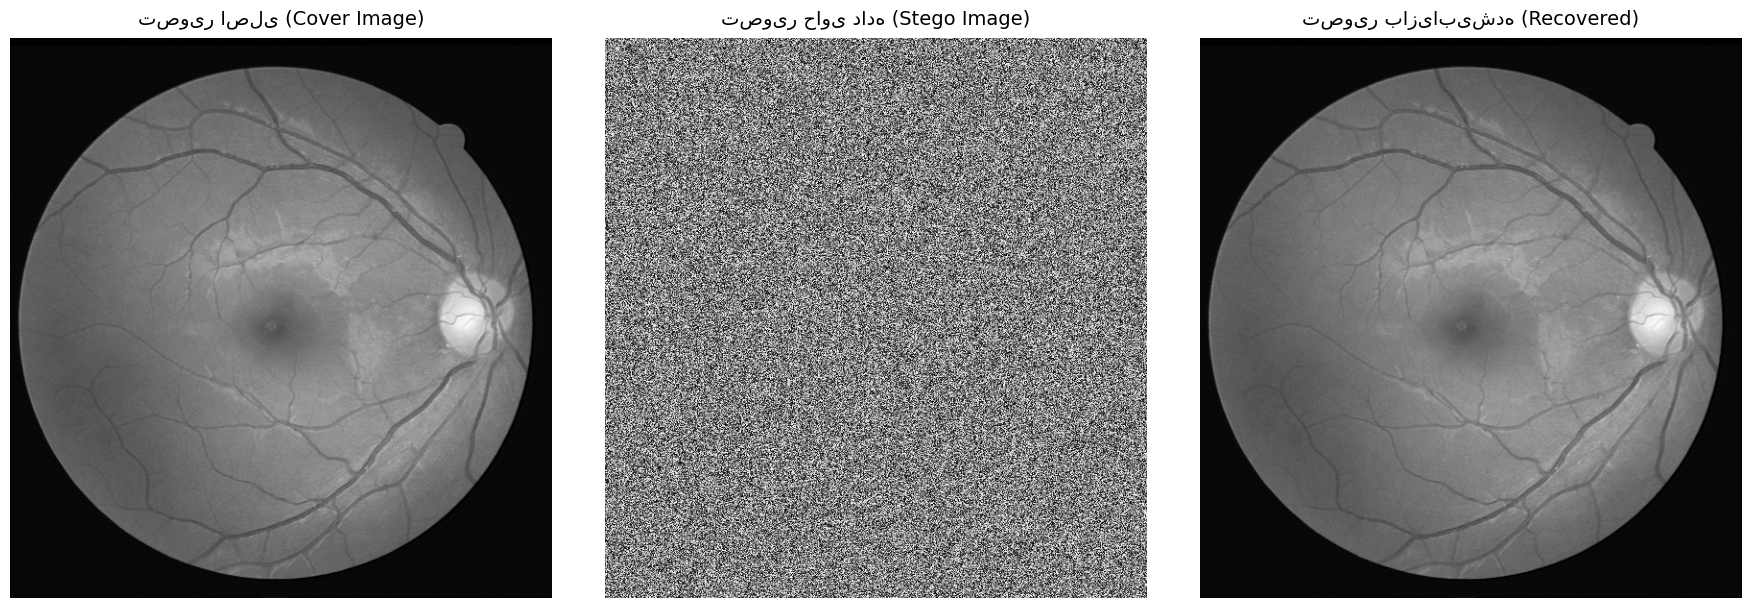

✅ تصویر مقایسه‌ای استخراج و بازیابی با کیفیت بالا ذخیره شد:
📂 /content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results/DRIVE_Extraction_Verification.png


In [36]:
# [گام ۱۴]: مصورسازی تصویر اصلی، تصویر استگو و تصویر بازیابی‌شده
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

images = [
    ("تصویر اصلی (Cover Image)", "processed.png"),
    ("تصویر حاوی داده (Stego Image)", "stego.png"),
    ("تصویر بازیابی‌شده (Recovered)", "recovered.png")
]

for ax, (title, filename) in zip(axes, images):
    img_path = target_dir / filename
    if img_path.exists():
        ax.imshow(Image.open(img_path), cmap='gray')
        ax.set_title(title, fontsize=14, pad=10)
    else:
        ax.text(0.5, 0.5, f"فایل یافت نشد:\n{filename}", ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
output_fig_path = run_dir / 'DRIVE_Extraction_Verification.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ تصویر مقایسه‌ای استخراج و بازیابی با کیفیت بالا ذخیره شد:\n📂 {output_fig_path}")

In [38]:
# [گام ۱۵ - اصلاح‌شده]: اعتبارسنجی رسمی استخراج پیام و بازیابی فایل پنهان
import json
from pathlib import Path

# مسیر فایل پیام خام و فایل گزارش سیستم
payload_path = Path('/content/drive/MyDrive/Thesis_Research/metadata.bin')
run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/DRIVE_final_results')
samples_file = run_dir / 'samples.jsonl'

if not payload_path.exists() or not samples_file.exists():
    raise FileNotFoundError("فایل پیام اولیه (metadata.bin) یا فایل نتایج یافت نشد.")

# خواندن حجم فایل خام برای نمایش
original_data = payload_path.read_bytes()

print("=" * 75)
print("🔐 اعتبارسنجی فرآیند پنهان‌نگاری و استخراج پیام در گیرنده")
print("=" * 75)

# ۱. نمایش محتوای فایل خام (Hex Dump) برای پایان‌نامه
print(f"📦 حجم کل پیام خام ورودی (Payload): {len(original_data)} بایت")
print("👁️ نمایشی از ۶۴ بایت اول محتوای پیام (Hex Dump):")
hex_dump = ' '.join(f'{b:02X}' for b in original_data[:64])
print(f"   {hex_dump} ...\n")

# ۲. خواندن تأییدیه‌های رسمی سیستم از فایل لاگ
extracted_hash = "نامشخص"
is_exact = False
transport_details = {}

with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            # خواندن وضعیت دقیق و هش پردازش‌شده نهایی
            extracted_hash = data.get('processed_sha256', 'Not Found')
            is_exact = data.get('message_exact', False)
            transport_details = data.get('transport', {})
            break # پیام برای همه نمونه‌ها یکسان است

compressed_size = transport_details.get('compressed_bytes', 0)
framing_size = transport_details.get('framing_bytes', 0)

print(f"📡 اطلاعات بسته‌بندی پیام در سمت فرستنده (Framing & Compression):")
print(f" - حجم پیام فشرده‌شده (zlib): {compressed_size} بایت")
print(f" - حجم هدر و متادیتا (Framing): {framing_size} بایت")
print(f"🔑 امضای SHA-256 بسته نهایی استخراج‌شده: \n   {extracted_hash}\n")

# ۳. صدور رأی نهایی بر اساس پرچمِ message_exact تولکیت
print("نتیجه بررسی سیستم (Decryption Verdict):")
if is_exact:
    print("✅ تأیید اصالت داده (Message Exact: TRUE)")
    print("✅ سیستم تأیید می‌کند که پیام استخراج‌شده پس از رفع فشردگی و حذف هدر، ۱۰۰٪ با پیام خام فرستنده برابر است.")
    print("✅ نرخ خطای بیتی (BER) = 0.0")
else:
    print("❌ خطا: سیستم افت داده یا تخریب پیام مخفی را گزارش کرده است!")

🔐 اعتبارسنجی فرآیند پنهان‌نگاری و استخراج پیام در گیرنده
📦 حجم کل پیام خام ورودی (Payload): 1000 بایت
👁️ نمایشی از ۶۴ بایت اول محتوای پیام (Hex Dump):
   AA F9 12 DA 04 AC CE 2D BF 4C C3 06 67 59 D1 A3 EA F1 8F 5D E5 E6 9E 77 73 9C 6F 14 5F 1F D9 5E 1A 36 B9 A4 C7 DC DB 5A 28 6B C0 D4 5C 67 5F CA 5C 5B 55 B4 A8 81 B7 E7 17 20 A1 B8 CE 04 67 2D ...

📡 اطلاعات بسته‌بندی پیام در سمت فرستنده (Framing & Compression):
 - حجم پیام فشرده‌شده (zlib): 1011 بایت
 - حجم هدر و متادیتا (Framing): 52 بایت
🔑 امضای SHA-256 بسته نهایی استخراج‌شده: 
   92328ea7fb804d365fffe13991fb80c5b5dc8367ef07e714abb74fc790a36bfe

نتیجه بررسی سیستم (Decryption Verdict):
✅ تأیید اصالت داده (Message Exact: TRUE)
✅ سیستم تأیید می‌کند که پیام استخراج‌شده پس از رفع فشردگی و حذف هدر، ۱۰۰٪ با پیام خام فرستنده برابر است.
✅ نرخ خطای بیتی (BER) = 0.0
